# Оценка sentence embeddings на русскоязычных NLI-парах

Тема НИР: «Оценка способности русскоязычных sentence embeddings различать семантическую близость и логическое противоречие в парах предложений».

## Цель эксперимента

Оценить, насколько cosine similarity между русскоязычными sentence embeddings позволяет различать семантически близкие, нейтральные и логически противоречивые пары предложений.

In [1]:
%cd /content
!rm -rf /content/nir-sentence-embeddings

/content


In [2]:
# Ячейка для запуска в Google Colab.
# Если репозиторий уже склонирован и зависимости установлены, эту ячейку можно пропустить.
# В Colab не устанавливаем пакет jupyter из requirements.txt, чтобы не конфликтовать с google-colab.
%cd /content
!git clone https://github.com/yaroslav2308/nir-sentence-embeddings.git
%cd nir-sentence-embeddings
!grep -v "^jupyter$" requirements.txt > /tmp/requirements-colab.txt
!pip install -r /tmp/requirements-colab.txt

/content
Cloning into 'nir-sentence-embeddings'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 33 (delta 10), reused 31 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 12.37 KiB | 218.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/nir-sentence-embeddings


In [3]:
import sys
from pathlib import Path

repo_path = Path.cwd()
if str(repo_path) not in sys.path:
    sys.path.append(str(repo_path))

# Альтернативно в Colab после clone можно явно указать путь:
# sys.path.append("/content/nir-sentence-embeddings")

In [4]:
import pandas as pd
from matplotlib import pyplot as plt

from src.data import add_text_stats, load_xnli_ru, sample_balanced
from src.evaluation import (
    aggregate_by_label,
    compute_auc_entailment_vs_contradiction,
    compute_delta_entailment_contradiction,
    get_high_similarity_contradictions,
)
from src.models import compute_sentence_transformer_similarity, compute_tfidf_similarity
from src.visualization import plot_similarity_by_label

In [5]:
df = load_xnli_ru(split="validation")
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ru/train-00000-of-00001.parquet:   0%|          | 0.00/70.0M [00:00<?, ?B/s]

ru/test-00000-of-00001.parquet:   0%|          | 0.00/477k [00:00<?, ?B/s]

ru/validation-00000-of-00001.parquet:   0%|          | 0.00/239k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5010 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2490 [00:00<?, ? examples/s]

,premise,hypothesis,label
0,"И он сказал: Мама, я дома.","Он позвал маму, как только вышел из школьного ...",neutral
1,"И он сказал: Мама, я дома.",Он не произнес ни слова.,contradiction
2,"И он сказал: Мама, я дома.","Он сказал матери, что уже добрался домой.",entailment
3,"Я не знал, что мне предстояло сделать и все та...","Я раньше не был в Вашингтоне, поэтому, получив...",neutral
4,"Я не знал, что мне предстояло сделать и все та...","Я точно знал, что мне нужно сделать, когда вхо...",contradiction


In [6]:
sample_df = sample_balanced(df, n_per_class=300, random_state=42)
sample_df = add_text_stats(sample_df)
sample_df["label"].value_counts()

,count
label,
contradiction,300
neutral,300
entailment,300


In [7]:
sample_df["tfidf_similarity"] = compute_tfidf_similarity(sample_df)
sample_df[["premise", "hypothesis", "label", "tfidf_similarity"]].head()

,premise,hypothesis,label,tfidf_similarity
0,"Уважаемый Доктор Спунер, любезный человек с с...",Доктор Спунер покинул Нью Колледж после двадца...,contradiction,0.119640
1,"последний контракт, который был выигран Virgin...",Контракты выявили немало спорных моментов у юр...,neutral,0.000000
2,"Рациональные ожидания выросли, частично, из по...",Никого не интересовал реальный трейдинг на фон...,contradiction,0.018920
3,Вклад работодателя в программы социального стр...,Работодатели вкладывают в социальные программы.,entailment,0.145792
4,"Моя бабушка родилась в 1910 году, она была мал...",Моя бабушка родилась в 1899 году.,contradiction,0.560387


In [8]:
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
sample_df["st_similarity"] = compute_sentence_transformer_similarity(
    sample_df,
    model_name=model_name,
    batch_size=32,
)
sample_df[["premise", "hypothesis", "label", "st_similarity"]].head()

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

,premise,hypothesis,label,st_similarity
0,"Уважаемый Доктор Спунер, любезный человек с с...",Доктор Спунер покинул Нью Колледж после двадца...,contradiction,0.587693
1,"последний контракт, который был выигран Virgin...",Контракты выявили немало спорных моментов у юр...,neutral,0.400501
2,"Рациональные ожидания выросли, частично, из по...",Никого не интересовал реальный трейдинг на фон...,contradiction,0.380260
3,Вклад работодателя в программы социального стр...,Работодатели вкладывают в социальные программы.,entailment,0.797224
4,"Моя бабушка родилась в 1910 году, она была мал...",Моя бабушка родилась в 1899 году.,contradiction,0.720771


In [9]:
aggregate_by_label(sample_df, "tfidf_similarity")

,label,count,mean,std,median,min,max
0,contradiction,300,0.113631,0.122269,0.086313,0.0,0.562298
1,entailment,300,0.171422,0.162506,0.138331,0.0,0.832679
2,neutral,300,0.103167,0.119382,0.073334,0.0,0.589089


In [10]:
aggregate_by_label(sample_df, "st_similarity")

,label,count,mean,std,median,min,max
0,contradiction,300,0.431168,0.186125,0.433848,-0.016202,0.907451
1,entailment,300,0.652786,0.154003,0.667982,0.214873,0.973722
2,neutral,300,0.516406,0.184037,0.521441,-0.002648,0.919979


In [11]:
for score_column in ["tfidf_similarity", "st_similarity"]:
    delta = compute_delta_entailment_contradiction(sample_df, score_column)
    auc = compute_auc_entailment_vs_contradiction(sample_df, score_column)
    print(f"{score_column}: delta={delta:.4f}, ROC-AUC={auc:.4f}")

tfidf_similarity: delta=0.0578, ROC-AUC=0.6037
st_similarity: delta=0.2216, ROC-AUC=0.8176


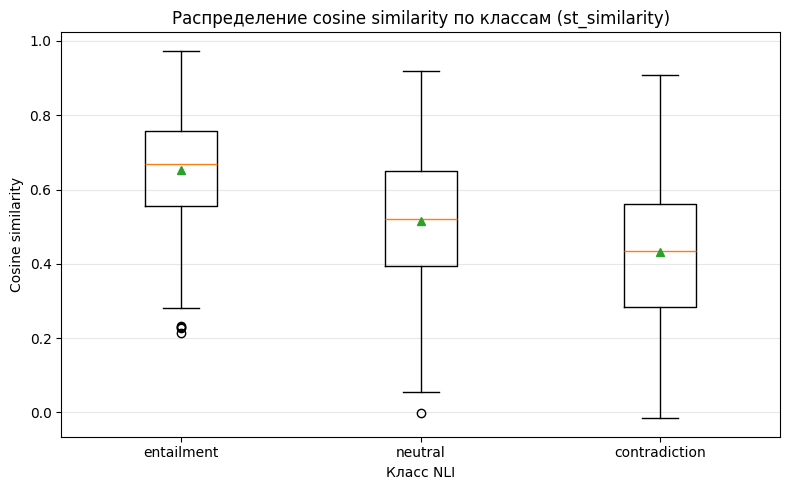

In [12]:
fig = plot_similarity_by_label(sample_df, "st_similarity")
plt.show()

In [13]:
columns = ["premise", "hypothesis", "label", "st_similarity", "lexical_overlap"]
get_high_similarity_contradictions(sample_df, "st_similarity", top_n=10)[columns]

,premise,hypothesis,label,st_similarity,lexical_overlap
0,Джереми Питт ответил на смех проклятием.,Джереми Пит ответил на смех ухмылкой и ударом ...,contradiction,0.907451,0.285714
1,Сегодня эти германизмы даже в США не остаются.,Эти германизмы больше не используются в Соедин...,contradiction,0.903214,0.333333
2,"Предполагается, что уровень загрязнения воздух...","Независимо от степени загрязнения воздуха, оно...",contradiction,0.838970,0.173913
3,"Кроме того, немногие почтовые службы платят св...",Почтовые работники в США зарабатывают гораздо ...,contradiction,0.838143,0.120000
4,В качестве предположительного адреса пребывани...,Михдхар чудесно провел время в отеле Marriott ...,contradiction,0.833413,0.285714
5,"Когда гражданское общество затыкает себе уши,...",Сумасшедшие идеи набирают популярность в гражд...,contradiction,0.832053,0.190476
6,"Главным, однако, является то, что в мире совсе...",По всему миру можно найти много Милошевичей.,contradiction,0.796689,0.047619
7,Соединенные Штаты не были основным источником ...,США определенно не поддерживали Аль-Каиду день...,contradiction,0.795764,0.115385
8,Юго-восточный сектор ПВО был проинформирован о...,Юго-восточный сектор ПВО получил сообщение о п...,contradiction,0.790387,0.388889
9,"Но именно от Старого Волка будет зависеть, зах...",Он хочет встретиться с тобой по поводу Старого...,contradiction,0.788388,0.142857


## Черновик интерпретации результатов

После запуска нужно сравнить распределения similarity для `entailment`, `neutral` и `contradiction`. Если contradiction-пары часто получают высокую similarity, это может означать, что embedding-модель хорошо улавливает тематическую и лексическую близость, но хуже отражает логическое противоречие, особенно при отрицании или замене ключевого признака на противоположный.

Особое внимание стоит уделить таблице contradiction-пар с высокой cosine similarity: такие примеры помогут описать типичные ошибки модели и ограничения cosine similarity как самостоятельного критерия логического отношения между предложениями.